# View symbolic regression results

This notebook plots the results of running symbolic regression with different hyperparameters. It also prints all of the suspected successful equations so they can be verified to recover the WLF equation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
default = pd.read_csv("symreg/eqns_simplified.csv")
threechem = pd.read_csv("symreg/eqns_chemconst3_simplified.csv")
noTref = pd.read_csv("symreg/eqns_noTref_simplified.csv")
constpen = pd.read_csv("symreg/eqns_constpen_simplified.csv")
weight = pd.read_csv("symreg/eqns_weighted_simplified.csv")
threechempen = pd.read_csv("symreg/eqns_chemconst3_constpen_simplified.csv")
noTrefpen = pd.read_csv("symreg/eqns_noTref_constpen_simplified.csv")
weightpen = pd.read_csv("symreg/eqns_constpen_weighted_simplified.csv")

## Generate the plot

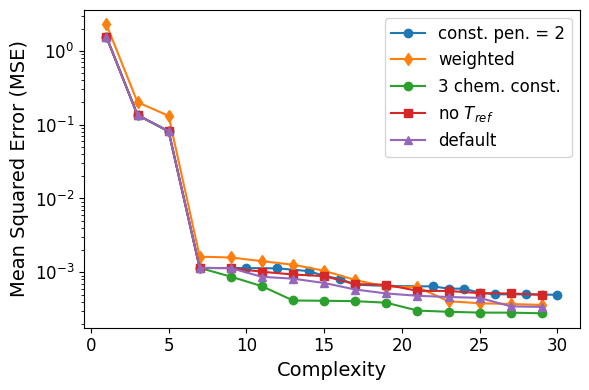

In [3]:
fig, ax1 = plt.subplots(figsize=(6, 4))

left, bottom, width, height = [0.5, 0.35, 0.39, 0.27]

ax1.plot(constpen["complexity"], constpen["loss"], label="const. pen. = 2", marker="o")
ax1.plot(weight["complexity"], weight["loss"], label="weighted", marker="d")
ax1.plot(threechem["complexity"], threechem["loss"], label="3 chem. const.", marker="o")
ax1.plot(noTref["complexity"], noTref["loss"], label=r"no $T_{ref}$", marker="s")
# ax1.plot(weightpen['complexity'],weightpen['loss'], label='weighted and const. pen. = 2',marker='d')
# ax1.plot(threechempen['complexity'],threechempen['loss'], label='3 chem. const. and const. pen. = 2',marker='o')
# ax1.plot(noTrefpen['complexity'],noTrefpen['loss'], label=r'no $T_{ref}$ and const. pen. = 2',marker='s')
ax1.plot(default["complexity"], default["loss"], label="default", marker="^")

ax1.set_yscale("log")
ax1.set_xlabel("Complexity", fontsize=14)
ax1.set_ylabel("Mean Squared Error (MSE)", fontsize=14)

ax1.tick_params(axis="x", labelsize=12)
ax1.tick_params(axis="y", labelsize=12)

ax1.legend(fontsize=12)

plt.tight_layout()
plt.savefig('figures/LossComplex.jpg',dpi=600)

## Look at the equations to verify they are WLF

`#1 = dT`; `#2 = Tref` (unless no Tref, in which case it is a learned constant); `#i` where `i` is 3 or greater is a learned constant.

In [4]:
names = ['threechem', 'noTref', 'constpen', 'weight', 'default', 'noTrefpen', 'weightpen']
df_list = [threechem, noTref, constpen, weight, default, noTrefpen, weightpen]

for i, df in enumerate(df_list):

    for j in range(len(df)):
        if df.iloc[j]["complexity"] == 7:

            print('-' * 50)
            print('Name:', names[i])
            print('Equation:', df.iloc[j].equation)
            print('Simplification Justification:', df.iloc[j].simplification_justification)

--------------------------------------------------
Name: threechem
Equation: f = #1 / ((#1 * #3) - #5); p1 = [-0.11125345, -0.10579444, -0.3987642, -0.17493449, -0.19659957, -0.12456501]; p2 = [-0.44716507, 0.1850353, 0.021411479, 0.032801617, 0.020693194, -0.13360769]; p3 = [11.73282, 10.662145, 59.765667, 20.843506, 21.4084, 19.158459]
Simplification Justification: nan
--------------------------------------------------
Name: noTref
Equation: f = #1 / (#3 - (#1 / #2)); p1 = [9.002029, 9.461648, 2.5265584, 5.6664195, 5.0848174, 8.02843]; p2 = [-11.743225, -10.671123, -59.482533, -20.90455, -21.402239, -19.147594]
Simplification Justification: nan
--------------------------------------------------
Name: constpen
Equation: f = #3 * (#1 / (((#4 * #1) / #3) + #2)); p1 = [-11.072189, -12.1845, -4.3726125, -8.133173, -7.944873, -8.878609]; p2 = [-13.622538, -15.694201, -7.5631266, -11.669732, -12.419854, -9.818923]
Simplification Justification: ['c3*x/(t+c4*x/c3)', 'c6*x/(c7+x)']
-----------